<a href="https://colab.research.google.com/github/ArtNizh/ML/blob/main/ML_%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0%D1%8F_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 2. Построение baseline-модели: от выбора парадигмы к метрикам качества
# Нижанковский Артем Дмитриевич

**Курс:** Машинное обучение. Безопасность ИИ-систем

**Формат:** индивидуально

**Среда:** Python, scikit-learn, PyTorch

**По материалам Лекции 2.1 и Лекции 2.2**

## Цель работы
Научиться выбирать тип задачи, датасет, baseline-модель и метрики качества, а также сопоставлять структуру данных с соответствующей архитектурой или классическим алгоритмом.

## Результаты обучения
После выполнения работы вы должны уметь:
- различать парадигмы обучения (supervised / unsupervised / reinforcement learning);
- выбирать модель под тип данных и задачу;
- строить baseline для классификации или регрессии;
- выбирать и интерпретировать метрики качества (accuracy, precision, recall, F1, MSE, RMSE, R²);
- сравнивать несколько моделей и делать обоснованный вывод о лучшем baseline.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.


## 0. Подготовка окружения

In [ ]:
# TODO: импортируйте необходимые библиотеки
# Подсказка: numpy, pandas, matplotlib, sklearn.*

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Постановка задачи

**Задание:** выберите один датасет из списка (или согласуйте свой с преподавателем) и определите тип задачи.

Варианты:
- **fetch_20newsgroups** — многоклассовая классификация;
- **diabetes** — регрессия.
- **MNIST** — классификация изображений, простая MLP-модель.

**Вопрос для отчёта:** к какой парадигме обучения относится ваша задача (supervised / unsupervised / reinforcement learning) и почему? Какой тип задачи вы решаете — классификация или регрессия?


_Ваш ответ:_ Задача относится к обучению с учителем (supervised learning), поскольку в наборе данных для каждого объекта заранее известно целевое значение, которое модель должна научиться предсказывать.
По типу это задача регрессии: целевая переменная непрерывная и числовая (показатель, характеризующий прогрессирование заболевания через год).

## 2. Загрузка и разведочный анализ данных (EDA)

In [ ]:
# TODO: загрузите выбранный датасет
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(as_frame=True)
df = diabetes.frame
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


Количество наблюдений: 442
Количество признаков: 10

Типы данных:
age       float64
sex       float64
bmi       float64
bp        float64
s1        float64
s2        float64
s3        float64
s4        float64
s5        float64
s6        float64
target    float64
dtype: object

Число пропусков во всём датасете: 0

Статистики целевой переменной:
count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64
            age       sex       bmi        bp        s1        s2        s3  \
count  442.0000  442.0000  442.0000  442.0000  442.0000  442.0000  442.0000   
mean    -0.0000    0.0000   -0.0000   -0.0000   -0.0000    0.0000   -0.0000   
std      0.0476    0.0476    0.0476    0.0476    0.0476    0.0476    0.0476   
min     -0.1072   -0.0446   -0.0903   -0.1124   -0.1268   -0.1156   -0.1023   
25%     -0.0373   -0.0446   -0.0342   -0.0367   -0.0342   -0.0304   -

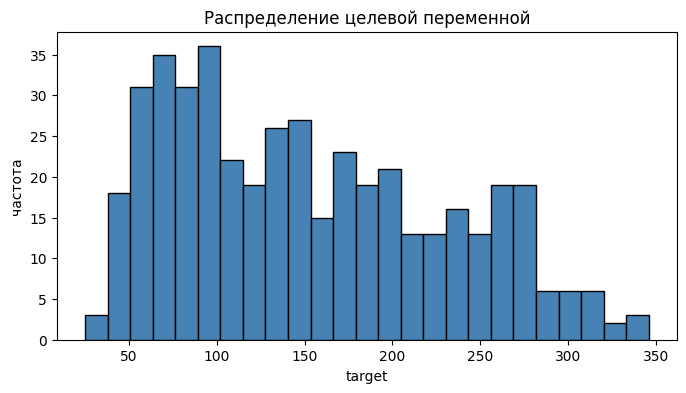

In [ ]:
# TODO: проведите разведочный анализ данных
# - размер выборки (df.shape)
# - типы признаков и целевая переменная (df.dtypes)
# - наличие пропусков (df.isna().sum())
# - баланс классов для классификации (df[target].value_counts())
# - базовые статистики (df.describe())

print("Количество наблюдений:", df.shape[0])
print("Количество признаков:", df.shape[1] - 1)

print("\nТипы данных:")
print(df.dtypes)

print("\nЧисло пропусков во всём датасете:", df.isna().sum().sum())

print("\nСтатистики целевой переменной:")
print(df['target'].describe())
print(df.describe().round(4))

# Баланс классов неприменим, так как это регрессия.
# Вместо этого посмотрим на распределение целевой переменной.
plt.figure(figsize=(8, 4))
plt.hist(df['target'], bins=25, edgecolor='black', color='steelblue')
plt.title('Распределение целевой переменной')
plt.xlabel('target')
plt.ylabel('частота')
plt.show()

**Вопрос для отчёта:** есть ли в данных пропуски, дисбаланс классов или сильно различающиеся масштабы признаков? Как это повлияет на выбор моделей и предобработки?

_Ваш ответ:_ Пропуски в данных отсутствуют. Так как задача является регрессией, дисбаланс классов в строгом смысле отсутствует. Однако по графику распределения целевой переменной видно, что больших значений target меньше, чем малых, поэтому присутствует небольшая асимметрия: модель будет чаще встречать объекты с меньшими значениями целевой переменной. Это стоит учитывать при анализе ошибок, поскольку редкие большие значения могут прогнозироваться хуже.

mean = 0, std одинаковые, данные нормированы

## 3. Предобработка данных

In [ ]:
# TODO: разделите данные на train/test (train_test_split)
# TODO: при необходимости выполните масштабирование признаков (StandardScaler / MinMaxScaler)
# TODO: при необходимости выполните кодирование категориальных признаков (OneHotEncoder / get_dummies)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

## 4. Обучение моделей

**Задание:** обучите не менее **трёх** моделей из списка (минимум одну классическую и минимум одну альтернативную):
- логистическая / линейная регрессия;
- дерево решений;
- k-NN;
- простой MLP.


In [ ]:
# TODO: импортируйте и обучите первую модель
from sklearn.linear_model import LinearRegression

# Модель 1: линейная регрессия (классическая)
model_1 = LinearRegression()
model_1.fit(X_train, y_train)

LinearRegression()

In [ ]:
# TODO: импортируйте и обучите вторую модель
from sklearn.tree import DecisionTreeRegressor

# Модель 2: дерево решений
model_2 = DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE)
model_2.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=3, random_state=42)

In [ ]:
# TODO: импортируйте и обучите третью модель
from sklearn.neighbors import KNeighborsRegressor

# Модель 3: Метод k-ближайших соседей (k-NN)
model_3 = KNeighborsRegressor(n_neighbors=7)
model_3.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=7)

## 5. Выбор и расчёт метрик качества

Для классификации используйте минимум **две** метрики из: accuracy, precision, recall, F1, confusion matrix.
Для регрессии используйте минимум **две** метрики из: MSE, RMSE, R².


In [ ]:
# TODO: рассчитайте метрики для каждой модели на тестовой выборке
# Подсказка: sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# либо mean_squared_error, r2_score для регрессии

from sklearn.metrics import mean_squared_error, r2_score

models = {
    'Linear Regression': model_1,
    'Decision Tree': model_2,
    'k-NN': model_3
}

metrics_data = []

for name, model in models.items():
    preds = model.predict(X_test)

    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    metrics_data.append({
        'Модель': name,
        'MSE': round(mse, 2),
        'R2': round(r2, 3)
    })

results_df = pd.DataFrame(metrics_data)
display(results_df)

,Модель,MSE,R2
0,Linear Regression,2848.31,0.485
1,Decision Tree,3511.57,0.365
2,k-NN,3053.06,0.448


Датасет маленький (442 объекта) и признаки уже стандартизированы, а связи между признаками и целевой переменной в основном линейные — поэтому простая линейная модель работает лучше гибких

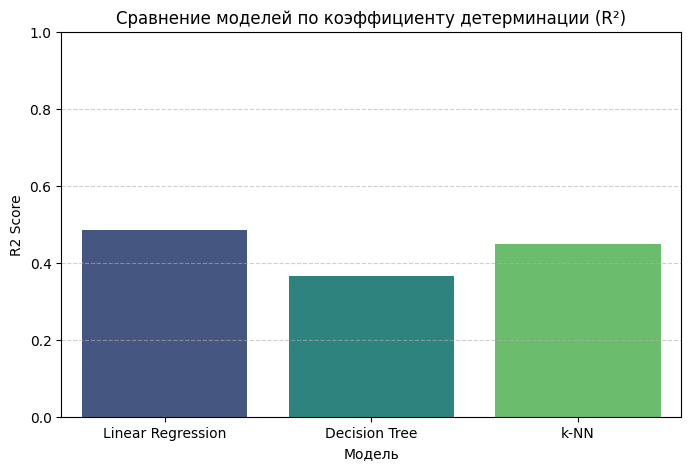

In [ ]:
# TODO: постройте минимум одну визуализацию:
# - confusion matrix, или
# - важность признаков (feature_importances_), или
# - график сравнения метрик по моделям, или
# - дерево решений (plot_tree), или
# - learning curve
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x='Модель', y='R2', hue='Модель', palette='viridis', legend=False)
plt.title('Сравнение моделей по коэффициенту детерминации (R²)')
plt.ylabel('R2 Score')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

**Вопрос для отчёта:** почему вы выбрали именно эти метрики? В каких случаях accuracy может вводить в заблуждение (например, при дисбалансе классов)?

_Ваш ответ:_ Для задачи регрессии я выбрал метрики MSE, RMSE и R². MSE сильно штрафует модель за большие промахи — это полезно, когда грубая ошибка критична. RMSE — это корень из MSE, он удобнее тем, что измеряется в тех же единицах, что и целевая переменная, поэтому его легко интерпретировать. R² показывает, какую долю разброса данных объясняет модель: единица — идеально, ноль — модель не лучше, чем просто предсказание среднего.

Accuracy используется только в классификации и вводит в заблуждение при сильном дисбалансе классов. Если почти все объекты принадлежат одному классу, модель может всегда предсказывать его и получать высокую accuracy, но при этом не находить редкий класс вообще. В регрессии аналог такой «глупой модели» — предсказание среднего значения, и именно с ним сравнивает R²

## 6. Анализ ошибок

Статистика ошибок:


,error,abs_error
count,111.00,111.00
mean,1.86,41.55
std,53.58,33.65
min,-153.66,0.74
25%,-25.84,13.92
50%,0.74,35.21
75%,40.38,62.24
max,128.81,153.66


Средняя ошибка: 1.86

Худшие предсказания:


,actual,predicted,error,abs_error
61,52.0,205.66,-153.66,153.66
109,52.0,185.59,-133.59,133.59
46,200.0,71.19,128.81,128.81
1,70.0,182.53,-112.53,112.53
27,77.0,187.17,-110.17,110.17


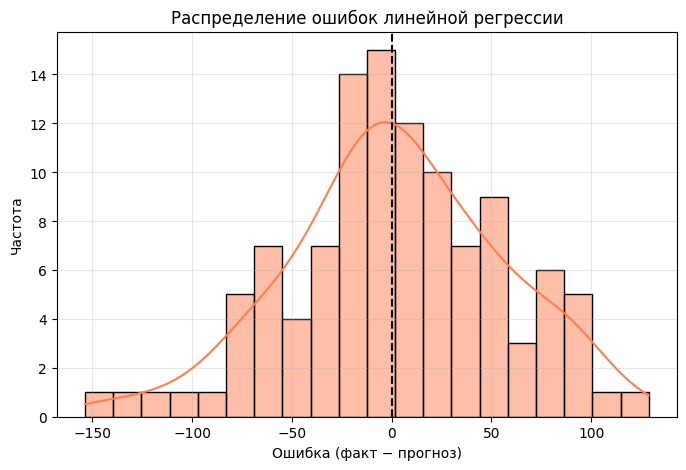

In [ ]:
# TODO: проанализируйте ошибки лучшей модели
# - какие объекты классифицируются неверно?
# - есть ли систематическая ошибка (например, путаница конкретных двух классов)?

# Анализ ошибок лучшей модели (Linear Regression)
y_pred = model_1.predict(X_test)
errors = y_test.values - y_pred

# Собираем всё в таблицу
errors_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_pred.round(2),
    'error': errors.round(2),
    'abs_error': np.abs(errors).round(2)
})

# Базовая статистика
print("Статистика ошибок:")
display(errors_df[['error', 'abs_error']].describe().round(2))

print(f"Средняя ошибка: {errors.mean():.2f}")

# Топ-5 худших предсказаний
print("\nХудшие предсказания:")
display(errors_df.sort_values('abs_error', ascending=False).head())

# Гистограмма ошибок
plt.figure(figsize=(8, 5))
sns.histplot(errors, bins=20, kde=True, color='coral')
plt.axvline(0, color='black', linestyle='--')
plt.xlabel('Ошибка (факт − прогноз)')
plt.ylabel('Частота')
plt.title('Распределение ошибок линейной регрессии')
plt.grid(alpha=0.3)
plt.show()

Распределение ошибок близко к нормальному и центрировано около нуля (средняя ошибка 1.86), что говорит об отсутствии систематического смещения. Однако разброс ошибок велик (std 53.58 при среднем target 152), а средняя абсолютная ошибка (41.55) заметно меньше std — значит, основную часть разброса создают выбросы. Анализ худших предсказаний показывает закономерность: модель завышает прогноз для объектов с низким target и занижает для объектов с высоким, то есть «стягивает» крайние значения к среднему. Это ожидаемо для линейной регрессии с MSE-лоссом на данных с правосторонней асимметрией целевой переменной

## 7. Сравнение моделей и вывод

**Вопрос для отчёта:** какая модель показала лучший результат по выбранным метрикам? Согласуется ли это с ожиданиями, учитывая структуру данных (линейность, размер выборки, число признаков)? Какую модель вы бы выбрали в качестве baseline и почему?

_Ваш ответ:_ Лучший результат показала линейная регрессия — у неё наименьшая ошибка и наибольший R² среди всех рассмотренных моделей. Это логично: в датасете diabetes мало объектов и мало признаков, а связи между признаками и целевой переменной в основном линейные. Поэтому простая линейная модель работает устойчиво и не переобучается. Дерево решений проигрывает, потому что даже с ограничением глубины подстраивается под случайные шумы. k-NN тоже отстаёт: в многомерном пространстве расстояние между точками теряет смысл, и «ближайшие соседи» оказываются не такими уж близкими. В качестве baseline беру линейную регрессию — она быстрая, простая и интерпретируемая, задаёт хорошую нижнюю планку. Если более сложная модель не обгоняет её заметно, значит усложнение не нужно.

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже

### С1. Кластеризация как альтернативный взгляд на данные
Примените unsupervised-подход (например, KMeans) к тем же признакам без использования целевой переменной. Сравните полученные кластеры с реальными классами/значениями целевой переменной. Обсудите: совпадает ли структура кластеров с реальной разметкой? Что это говорит о структуре данных?

### С2. Классический baseline vs простой MLP
Обучите простую нейросеть (MLPClassifier/MLPRegressor из sklearn, либо небольшую сеть на PyTorch) на тех же признаках и сравните её с лучшей классической моделью по тем же метрикам. Объясните, почему нейросеть выигрывает/проигрывает при данном объёме данных и числе признаков.

### С3. Устойчивость вывода о «лучшей» модели к выбору метрики
Постройте искусственный дисбаланс классов (например, undersampling одного класса) и пересчитайте метрики для всех моделей. Проверьте: меняется ли ранжирование моделей при использовании accuracy против F1/recall? Сделайте вывод о том, почему выбор метрики критичен при дисбалансе.

### С4. Кросс-валидация и доверительный интервал качества
Замените единичный train/test split на k-fold кросс-валидацию (cross_val_score) для всех моделей. Постройте boxplot распределения метрики по фолдам. Обсудите, насколько стабильны результаты моделей.


MLPRegressor — это класс из sklearn.neural_network, реализующий многослойный перцептрон (MLP) для задачи регрессии. По сути это простая полносвязная нейросеть: входной слой принимает признаки, один или несколько скрытых слоёв применяют линейное преобразование и нелинейную активацию, а выходной слой выдаёт одно числовое предсказание.

,model,RMSE,R2
0,Linear Regression,53.37,0.485
1,MLP,53.45,0.483


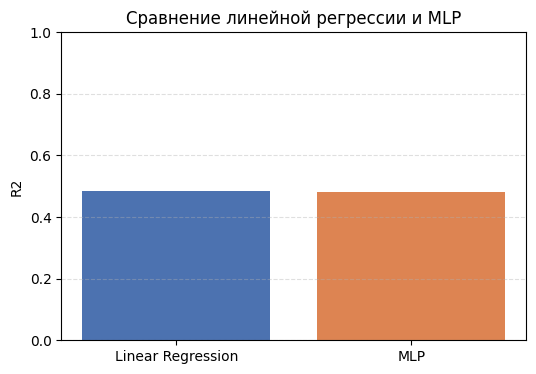

In [ ]:
#C2:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Простая нейросеть с небольшой архитектурой
mlp_model = MLPRegressor(
    hidden_layer_sizes=(24, 12), # Два скрытых слоя: 24 нейрона в первом, 12 во втором — сеть небольшая, чтобы не переобучаться на малых данных
    activation='relu',              # Функция активации ReLU — стандартный выбор, добавляет нелинейность
    max_iter=3000,
    random_state=RANDOM_STATE
)

mlp_model.fit(X_train, y_train)

comparison = []

for name, model in [('Linear Regression', model_1), ('MLP', mlp_model)]:
    pred = model.predict(X_test)

    comparison.append({
        'model': name,
        'RMSE': round(np.sqrt(mean_squared_error(y_test, pred)), 2),
        'R2': round(r2_score(y_test, pred), 3)
    })

comparison_df = pd.DataFrame(comparison)
display(comparison_df)

plt.figure(figsize=(6, 4))
plt.bar(comparison_df['model'], comparison_df['R2'], color=['#4C72B0', '#DD8452'])
plt.ylabel('R2')
plt.title('Сравнение линейной регрессии и MLP')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

Простая нейросеть на данном датасете не даёт заметного преимущества перед линейной регрессией, так как датасет diabetes имеет малый объём.

Кросс-валидация (k-fold CV). Данные делятся на k равных частей (фолдов). Затем модель обучается k раз: каждый раз один фолд служит тестом, остальные k−1 — обучением. В итоге каждая точка данных ровно один раз побывает в тесте. Результат — не одна метрика, а k значений, по которым видно и среднее качество, и его стабильность.

Среднее и std R² по фолдам:


,mean,std
model,,
Decision Tree,0.286,0.096
Linear Regression,0.482,0.055
k-NN,0.397,0.043


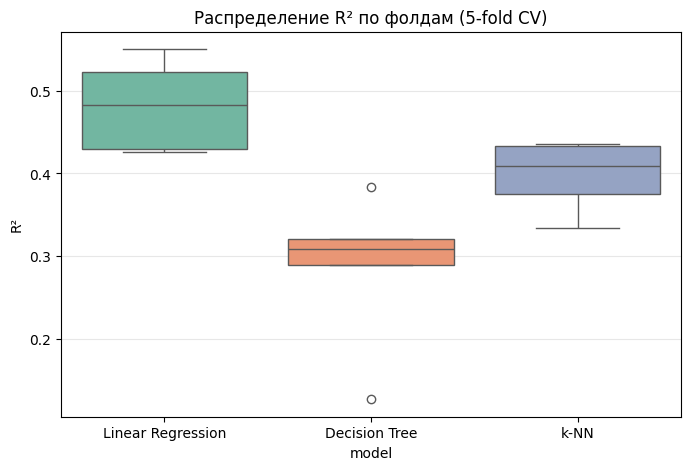

In [ ]:
# С4. Кросс-валидация и доверительный интервал качества
from sklearn.model_selection import cross_val_score

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=4, random_state=RANDOM_STATE),
    'k-NN': KNeighborsRegressor(n_neighbors=7)
}

# Собираем R² по фолдам для каждой модели
cv_results = []
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    for s in scores:
        cv_results.append({'model': name, 'R2': s})

cv_df = pd.DataFrame(cv_results)

# Среднее и разброс по фолдам
print("Среднее и std R² по фолдам:")
display(cv_df.groupby('model')['R2'].agg(['mean', 'std']).round(3))

# Boxplot распределения R²
plt.figure(figsize=(8, 5))
sns.boxplot(data=cv_df, x='model', y='R2',
            hue='model', palette='Set2', legend=False)
plt.title('Распределение R² по фолдам (5-fold CV)')
plt.ylabel('R²')
plt.grid(axis='y', alpha=0.3)
plt.show()

Кросс-валидация (5-fold) подтверждает вывод, сделанный на единичном train/test split: линейная регрессия — лучшая модель со средним R² = 0.482 и умеренным разбросом (std = 0.055). k-NN даёт более скромное, но самое стабильное качество (mean = 0.397, std = 0.043) — метод предсказуем, но уступает линейной модели. Дерево решений — худшее и самое нестабильное (mean = 0.286, std = 0.096): широкий ящик и два выброса на boxplot показывают, что результат сильно зависит от разбиения данных, что типично для деревьев на малых выборках.

---



## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Минимум 3 модели, минимум 2 метрики, минимум 1 визуализация.
